"Generations come, and generations go, but the earth lasts forever. The sun rises, and the sun sets, and then it rushes back to the place where it will rise again."

- Ecclesiastes 1:4-5

I became interested in Agent-Based Modelling (ABM) recently when I was searching for ways to simulate data with high fidelity, i.e., synthetic data that closely resembles real-world data. Serenpendiously, I found out about this book: Agent-based models and causal inference. I haven't finished reading everything yet, but the author, Gianluca Manzo, puts forward the idea that ABMs can be used for causal inference. In the book, he evaluates the ways ABM models differ or resemble more traditional methods in their assumptions. ABM models were originally developed to study self-organizing and emergent patterns in complex systems, but the interesting thing about them is that once you have a reasonably justified model and parameters, they turn into Counterfactual Machines. So I can see how that could work.

In parallel, I am also taking a numerical analysis course offered by L2C called "From Calculus to Computational Simulation." In this way, today's post is going to be a little different; I am going to present my final project in the course. Right away, let me make a disclaimer that I am not an ecologist nor a super expert on the methods I have used here. So I am going to make some speculations, and I apologize in case of any possible misunderstandings.

For starters, a little bit of history: in the 1920s, Vito Volterra was analyzing fish population dynamics on the Adriatic Sea, while Alfred Lotka was studying the concentration of chemicals during reactions. In one event that can only be described as the "unreasonable effectiveness of mathematics in the natural sciences", they independently arrived at what became known as the Lotka-Volterra Equations. Today, I plan to show you the application in Biology.

First, assume there are only two populations of interest, where:

$x(t) \ge 0$ is the population size of the prey species at time t, and

$y(t) \ge 0$ is the population size of the predator species.

Assume also that:

1. In the absence of the predator, the prey grows at a rate proportional to the current population; thus growing exponentially if left unchecked.
2. In the absence of the prey, the predator dies out since the prey is its only source of food;
3. The number of encounters between predator and prey is proportional to the product of their populations. Each such encounter tends to promote the growth of the predator and to inhibit the growth of the prey.

As a consequence of these assumptions, we are led to the following first-order, non-linear ordinary system of differential equations.

$$
\begin{aligned}
\frac{dx}{dt} &= \alpha x - \beta xy \\
\frac{dy}{dt} &= \delta xy - \gamma y
\end{aligned}
$$

Our objective is to determine the system's long-term behaviour as $t \rightarrow \infty$. Do populations flourish? Do they die out? In order to do that, we are going to analyze data from the Snowshoe Hare and the Canada Lynx. These populations are commonly thought to be the perfect example of competition between species that is compatible with the predictions given by the Lotka-Volterra equations.

# Case Study: Canadian Lynx-Hare

In [1]:
import pandas as pd
import plotnine as p9
import numpy as np
import matplotlib.pyplot as plt
import cmdstanpy
import arviz_plots as azp

from src.utils import plot_population_competition
from src.estimation import discrete, bayesian, evolution

In [2]:
%matplotlib inline

First of all, lets load and plot the data. After a quick cleansing, we can visualize the amount of pelts measured in thousands collected between 1900 and 1920.

In [3]:
lynx_hare_df = pd.read_csv("data/input/Howard2009.csv", skiprows=2).rename(columns=lambda x: x.strip().lower())

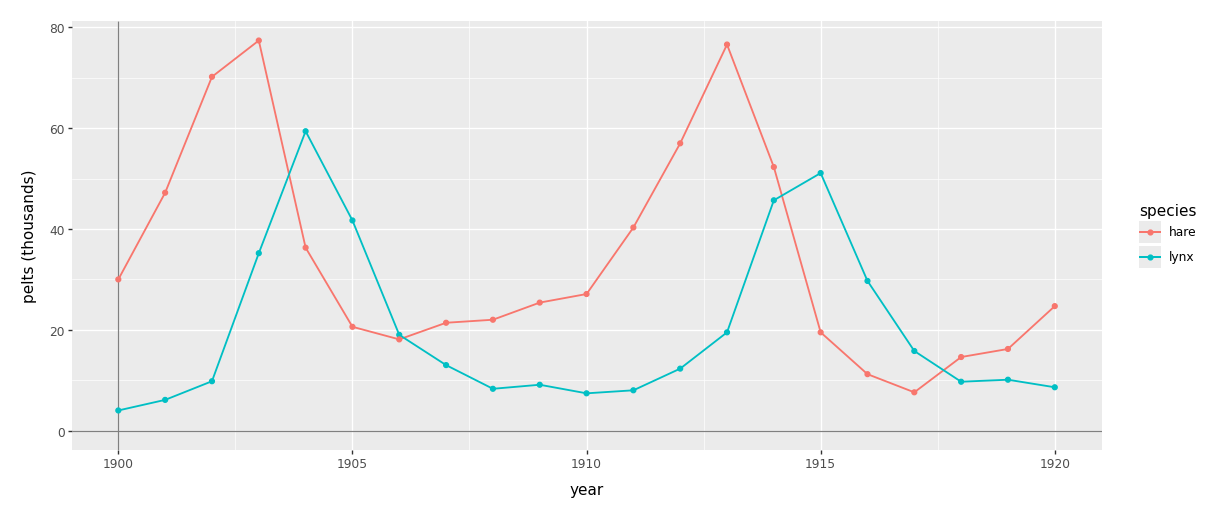

In [4]:
(
    p9.ggplot(lynx_hare_df.melt(id_vars="year", var_name="species", value_name="pelts")) +
    p9.aes("year", "pelts", color="species") +
    p9.geom_vline(xintercept=1900, color="grey") +
    p9.geom_hline(yintercept=0, color="grey") +
    p9.geom_line(size=0.75) +
    p9.geom_point(size=1.5) +
    p9.ylab("pelts (thousands)") +
    p9.theme(figure_size=(12, 5))
)

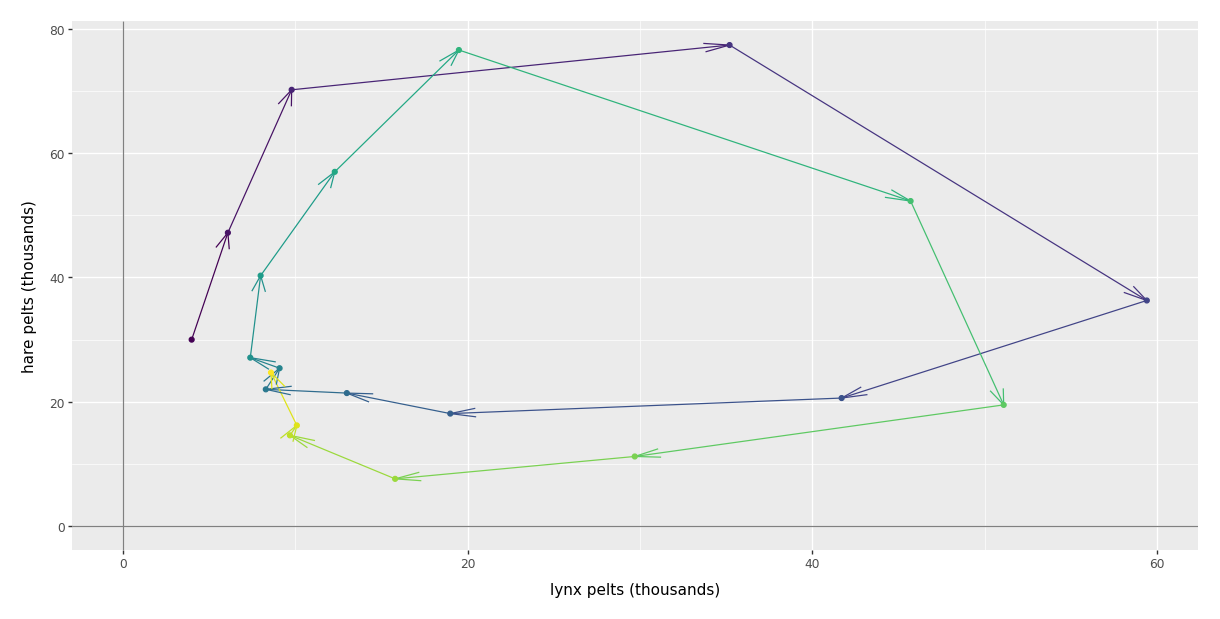

In [5]:
(
    p9.ggplot(lynx_hare_df) +
    p9.aes(x="lynx", y="hare", color="year") +
    p9.geom_vline(xintercept=0, color="grey") +
    p9.geom_hline(yintercept=0, color = "grey") +
    p9.geom_path(arrow = p9.arrow(angle = 15, length = 0.15)) +
    p9.geom_point(size = 1.5) +
    p9.xlab("lynx pelts (thousands)") +
    p9.ylab("hare pelts (thousands)") +
    p9.theme(legend_position="none", figure_size=(12, 6))
)

# Parameter Estimation

The first step to reach our goal is to estimate equations coefficients that best fit the data.

## Discrete Linear System

Instead of jumping straight into the Lotka-Volterra equations, let's take a step back and consider the following Linear Discrete System. Here, we can imagine "a" as being the proportion of the predator population that survives from one year to the next, "b" as the contribution of the prey species to the growing of the predator, "c" as a predation parameter which is negative, i.e., the predator contributes to the decrease of the prey and, finally, "d" as the rate the prey would grow each year if left unchecked.

$$Y_{t+1} = a Y_t + b X_t$$
$$X_{t+1} = -c Y_t + d X_t$$

Although this linear simplification is most likely wrong, the discrete System should be a decent or even better approximation to describe the Hare-Lynx system behavior than the continuous equations I showed you in the beginning, since population sizes are measured only once a year in our dataset.

Let's rearrange the system in matricial form as: 

$$
\begin{bmatrix}
Y_{t+1} \\
X_{t+1}
\end{bmatrix}
=
\begin{bmatrix}
a & b \\
-c & d
\end{bmatrix}
\begin{bmatrix}
Y_t \\
X_t
\end{bmatrix}
$$

Consider the initial populations

$$
\vec{s_0}
=
\begin{bmatrix}
Y_0 \\
X_0
\end{bmatrix}
$$

Then, if we recursevely apply the definition, we get that:

$$
\vec{s_1}
=
A
\vec{s_0}
$$

$$
\vec{s_2} = A A \vec{s_0} = A^2 \vec{s_0}
$$

$$
\vec{s_k}
=
A^k
\vec{s_0}
$$

It turns out that analyzing the system long-term behaviour is akin to calculating powers of the coefficient matrix. However, that can be numerically unstable and expensive. Thankfully, eigenvalues and eigenvectors come to the rescue.

Since the eigenvectors of A, $\vec{v_0}$ and $\vec{v_1}$, form a basis for R², we can write the initial population vector as a linear combination of these eigenvectors.

$$
\vec{s_k} = \alpha_0 \lambda_0 ^ k \vec{v_0} + \alpha_1 \lambda_1 ^ k \vec{v_1}
$$

Given the formula above, once we have the parameters — a, b, c and d  — we can analyze the eigenvalues of A to understand the long-term behaviour of the system. Let's try to estimate the parameters with ol' reliable Least Squares.

In [6]:
years = lynx_hare_df["year"].values
lynx_obs = lynx_hare_df["lynx"].values
hare_obs = lynx_hare_df["hare"].values

In [7]:
theta, fitted, residuals = discrete.fit(lynx_obs, hare_obs)

In [8]:
theta

array([[ 0.47149277,  0.38197845],
       [-0.35044069,  1.06802234]])

In [9]:
eigvals = np.linalg.eigvals(theta)
eigvals

array([0.76975756+0.21189362j, 0.76975756-0.21189362j])

In [10]:
np.abs(eigvals)

array([0.79838938, 0.79838938])

Since eigenvalues are complex and smaller than one in magnitude, we might be tempted to conclude that the populations will oscillate while slowly decaying and eventually dying out. But it seems unlikely for any estimation procedure to give us back parameters where the eigenvalues land exactly on the unit circle, so I wouldn´t worry about the fluffy guys, at least for now. Also, given what I've just said, it might seem like the discrete model was a complete waste of time. But first, remember there are better ways to go about estimating the parameters than Least Squares.

However, now is a good moment to talk about the limitations we are facing regarding data collection. The data we're analyzing is the same as that used by Bob Carpenter's Stan Guide that you may find here. From what I understand, Bob got the data from a 2009 study that came from Hudson’s Bay Company, the largest Canadian fur trapper. As he mentions it, there are many confouding factors such as the weather, plagues, and the fact that lynxes are easier to trap when they are hungry, which correlates with the decline of the hare population. These aren't issues I am going to deal with, but the point is that uncertainty quantification seems essential for our objective to understand what may happen in the long term. This way, we're going to stop the discrete system analysis for now, given that I am unsure about how to do that.

Here, I should also mention that I have found other datasets online that allegedly also came from the Hudson’s Bay Company, and they are longer and noisier than the one we got from the Stan Guide. I will just leave them in the GitHub repo, and you may redo the analysis on your own. Finally, remember we try our best to do Iterative Science in this blog; and, if nothing else, we at least learned that the populations will likely remain oscillating in the short term.

## Continuos System

To the best of my knowledge, the system of equations I've shown you in the beginning doesn't have an analytical solution. However, we can do a qualitative analysis. You may find the full qualitative analysis at Wikipedia; it's similar to what we've done for the discrete system. For now, let me just say that we can see that the system has equilibrium solutions at:

$$\frac{dx}{dt} = 0: \alpha x - \beta x y = 0 \implies x = 0 \lor y = \frac{\alpha}{\beta}$$
$$\frac{dy}{dt} = 0: \delta x y - \gamma y = 0 \implies y = 0 \lor x = \frac{\gamma}{\delta}$$

Looking at the direction field, solutions seem to be ellipses around $(\frac{\gamma}{\delta}, \frac{\alpha}{\beta})$ and the origin is a saddle point, i.e., lynxes become extinct only if the initial hare population is zero and, on the other hand, hares grow exponentially if the initial lynx population is zero. I am going to revisit this analysis later, so keep it in mind. Below, I am also showing the numerical solution for a given set of parameters and one initial condition. We can see that the phase portrait and population evolution over time resemble the empirical data we have, but I am not going to tell you how I arrived at these particular coefficients for now.

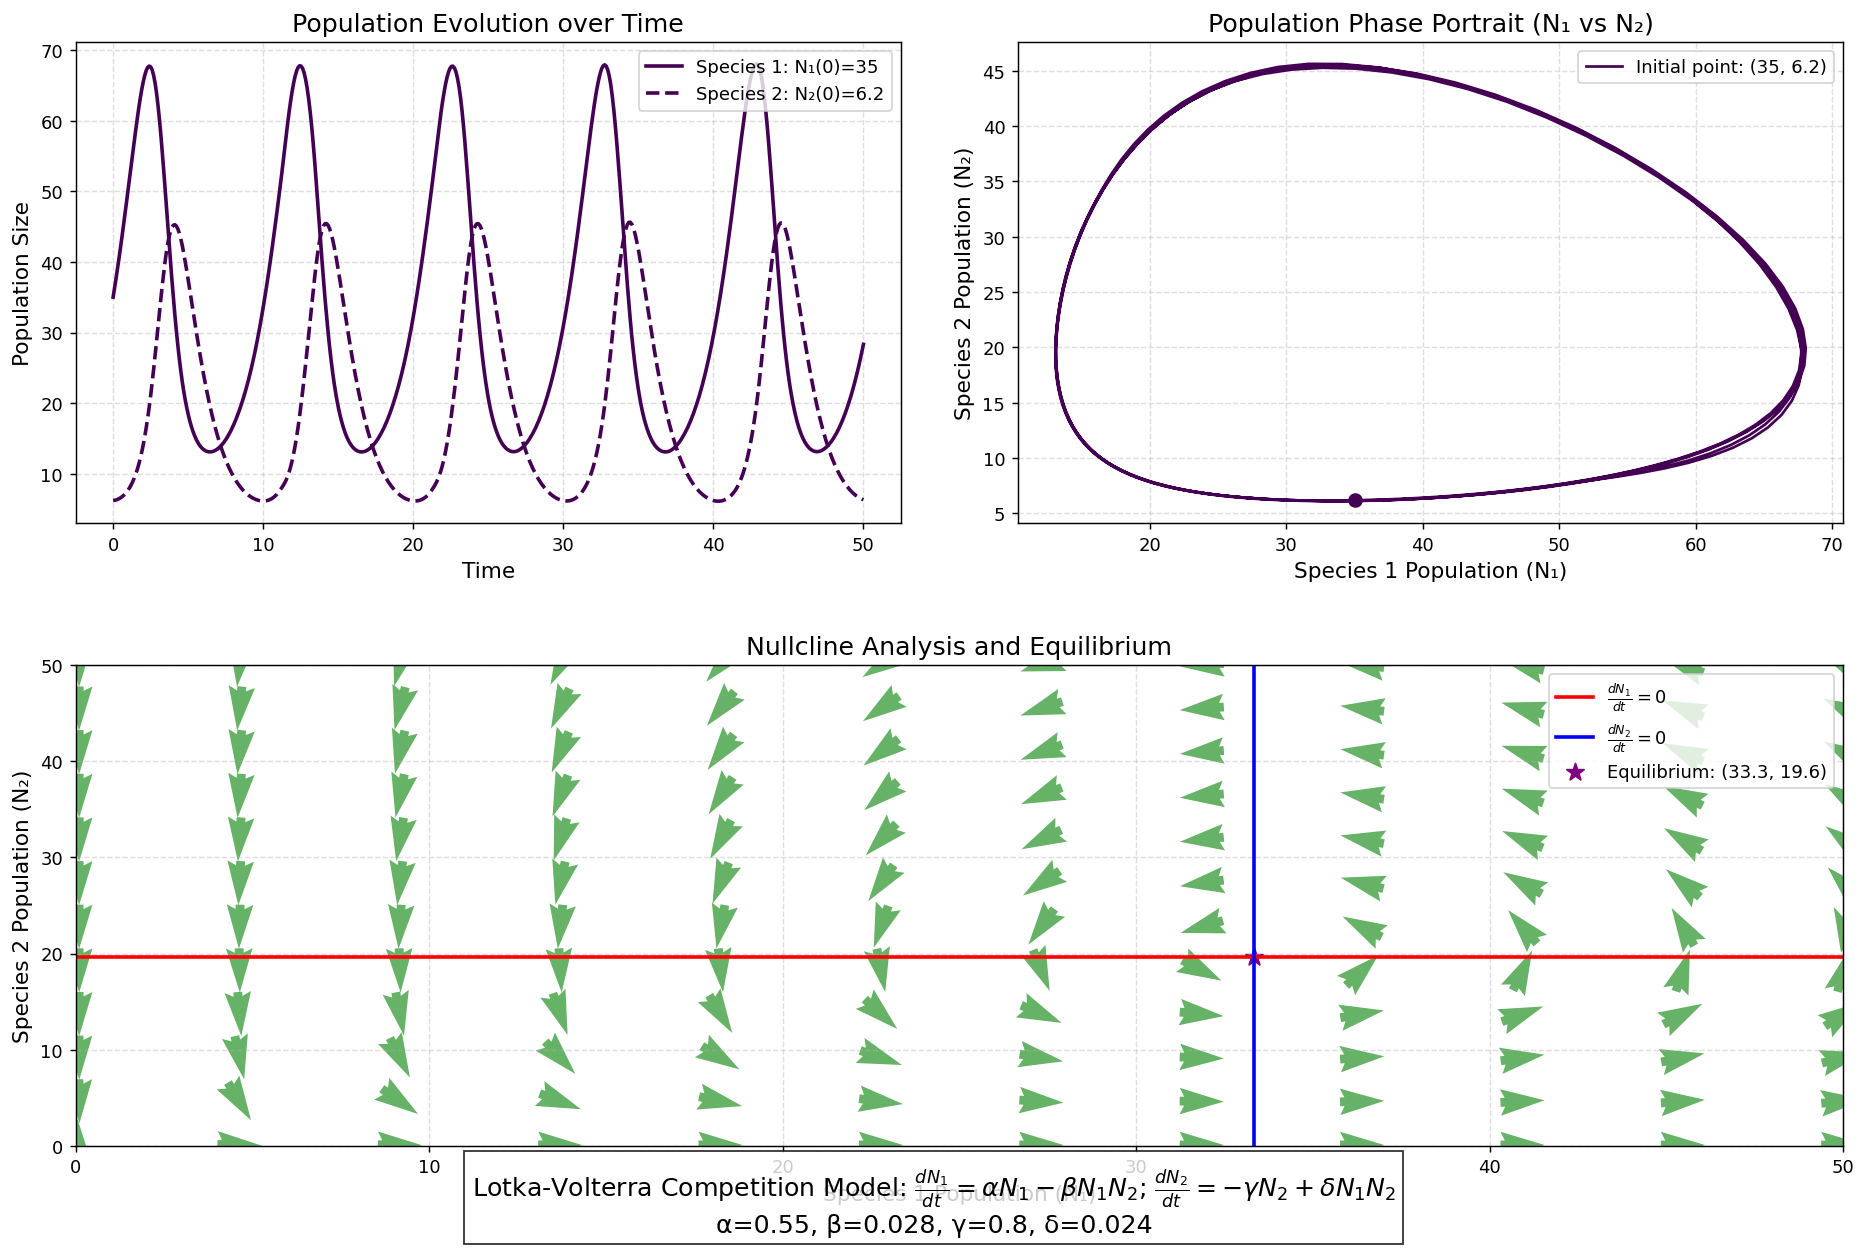

In [11]:
plot_population_competition(a=0.55, b=0.028, c=0.8, d=0.024, initial_conditions=[(35, 6.2)])

My first attempt to find the Equation's parameters also relied on Least Squares, but that didn't work out. So I decide to bring the big guns inside SciPy to see if they would work, and I ended up picking Differential EVolution.

### Evolution Fit

In [12]:
bounds = [
    (0.1, 1.5),
    (0.01, 0.08),
    (0.1, 1.5),
    (0.01, 0.08),
    (20.0, 45.0),
    (2.0, 10.0)
]

alpha, beta, gamma, delta, H0, L0 = evolution.fit(years, hare_obs, lynx_obs, bounds)

print(f"α={alpha:.4f}, β={beta:.4f}, γ={gamma:.4f}, δ={delta:.4f}\nH0={H0:.2f}, L0={L0:.2f}")

α=1.3891, β=0.0798, γ=0.3042, δ=0.0798
H0=43.48, L0=9.71


In [13]:
t0, t1, tn = lynx_hare_df["year"].min().item(), lynx_hare_df["year"].max().item(), 2020

In [14]:
sol = evolution.predict((alpha, beta, gamma, delta), [H0, L0], t0, tn)

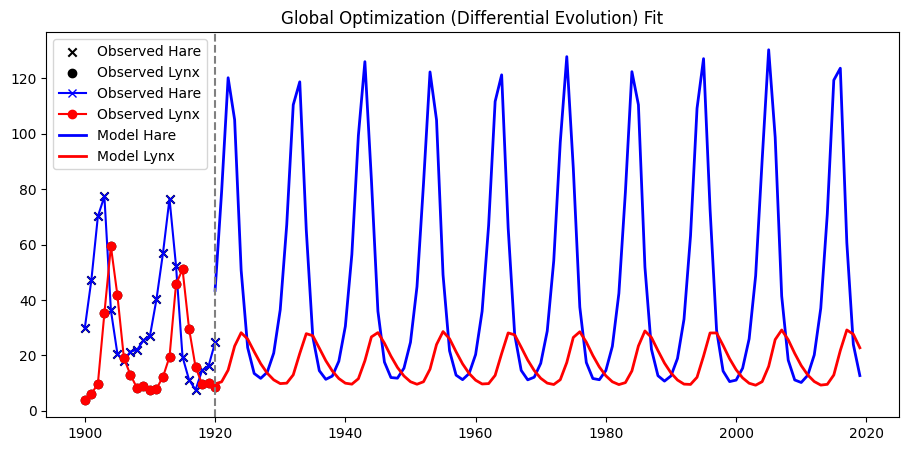

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(years, hare_obs, color='black', marker='x', label='Observed Hare')
ax.scatter(years, lynx_obs, color='black', marker='o', label='Observed Lynx')
ax.plot(years, hare_obs, color='blue', marker='x', label='Observed Hare')
ax.plot(years, lynx_obs, color='red', marker='o', label='Observed Lynx')
ax.plot(np.arange(t1, tn), sol[1].T[:(tn-t1), 0], color='blue', linewidth=2, label='Model Hare')
ax.plot(np.arange(t1, tn), sol[1].T[:(tn-t1), 1], color='red', linewidth=2, label='Model Lynx')
ax.axvline(x=1920, color='gray', linestyle='--')
ax.set_title("Global Optimization (Differential Evolution) Fit")
ax.legend()
plt.savefig("img/02_continuos_system_predictions_evolution.jpg")
plt.show()

The fit seems to severely overestimate the size of the Hare population while also strongly underestimating the Lynx population, but at least we got something periodic and in the right order, i.e., the hares peak before lynxes and one population growth is associated with the decay of the other. We also can see the famous ten years cycle. Some questions remain: can we get a better fit? Can we get uncertainty quantification?

## Bayesian Fit

### Linear Regression Analogy

Traditionally, we write Linear Regression as the equation below and find each $\beta$ and $\beta_0$ by minimizing the sum of squared errors.

$$y_i = \beta_0 + \beta x_i + \varepsilon_i$$

$$\varepsilon_i \sim \mathcal{N}(0,\ \sigma)$$

But this is equivalent to maximizing the probability of the observed data under additive noise. Hence, the expression below is just as valid.

$$Y_i \sim \mathcal{N}(\beta_0 + \beta x_i,\ \sigma)$$

Here, we are going to be doing something similar. However, there are some caveats. First, we'ŕe using a 4th order Runge-Kutta method inside Stan to solve the Lotka-Volterra equations and use that as the expected value, instead of the linear combination of covariates we're used to.   

Initial populations are properly treated as latent variables, and errors are considered multiplicative, not additive. Finally, we also need to specify our prior knowledge about the parameters in the form of prior distributions to be fully Bayesian. 

The full stan model can be found on GitHub. For more information around stuff like priors and a better explanation about the Bayesian Model, see the Stan tutorial. Here, I am also leaving out a lot of Bayesian Workflow steps. I suggest you fill in the missing parts and submit a PR. Feel free to also submit another PR with the solutions for the problems on the Stan Guide.

In [16]:
# cmdstanpy.install_cmdstan(version="2.38.0", overwrite=True, cores=4)

In [17]:
N = lynx_hare_df.shape[0] - 1
ts = np.arange(1, N + 1)
y_init = lynx_hare_df.loc[:, ["hare", "lynx"]].iloc[0].values
y = lynx_hare_df.iloc[1:].loc[:, ["hare", "lynx"]].values

lynx_hare_data = dict(N=N, ts=ts, y_init=y_init, y=y)

In [18]:
idata = bayesian.fit(lynx_hare_data, "lotka_volterra_model.stan")

13:01:08 - cmdstanpy - INFO - CmdStan start processing
13:01:08 - cmdstanpy - INFO - Chain [1] start processing
13:01:08 - cmdstanpy - INFO - Chain [2] start processing
13:01:08 - cmdstanpy - INFO - Chain [3] start processing
13:01:08 - cmdstanpy - INFO - Chain [4] start processing
13:01:19 - cmdstanpy - INFO - Chain [4] done processing
13:01:20 - cmdstanpy - INFO - Chain [1] done processing
13:01:22 - cmdstanpy - INFO - Chain [3] done processing
13:01:28 - cmdstanpy - INFO - Chain [2] done processing
13:01:28 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: lognormal_lpdf: Location parameter[1] is -nan, but must be finite! (in 'lotka_volterra_model.stan', line 65, column 4 to column 39)
	Exception: lognormal_lpdf: Location parameter[1] is -nan, but must be finite! (in 'lotka_volterra_model.stan', line 65, column 4 to column 39)
	Exception: lognormal_lpdf: Location parameter[1] is -nan, but must be finite! (in 'lotka_volterra_model.stan', line 65, column 4 to column 

                  Mean      MCSE    StdDev       MAD         5%        50%  \
lp__        -14.007800  0.060966  2.203730  2.055930 -18.072700 -13.640500   
theta[1]      0.547796  0.001952  0.062923  0.061200   0.448562   0.544979   
theta[2]      0.027799  0.000123  0.004184  0.004064   0.021422   0.027591   
theta[3]      0.799077  0.002890  0.089469  0.086906   0.663437   0.794627   
theta[4]      0.024045  0.000109  0.003508  0.003314   0.018892   0.023834   
...                ...       ...       ...       ...        ...        ...   
y_rep[18,2]  11.846500  0.051767  3.246790  2.934470   7.376050  11.439300   
y_rep[19,1]  20.222400  0.090652  5.493090  5.009530  12.764500  19.569500   
y_rep[19,2]   7.998560  0.036451  2.232640  1.980650   4.964140   7.734170   
y_rep[20,1]  28.889100  0.123515  7.881820  7.018130  18.345900  27.841600   
y_rep[20,2]   6.324330  0.029949  1.759150  1.589010   3.928540   6.091800   

                   95%  ESS_bulk  ESS_tail  ESS_bulk/s     R_ha

We finished sampling and it doesn't look like there were any problems. You can see the parameters posterior distribution below. 

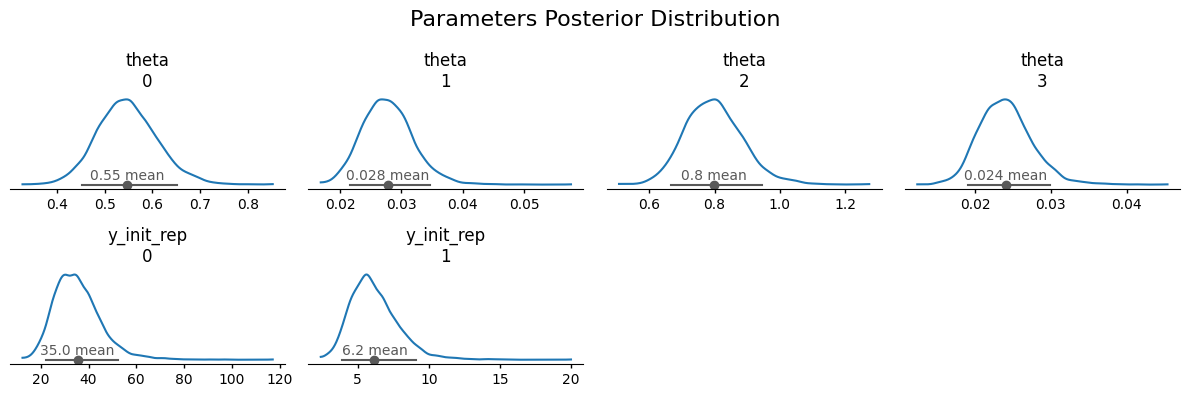

In [19]:
ax = azp.plot_dist(
    idata,
    var_names=["theta", "y_init_rep"],
    figure_kwargs={"figsize": (12, 4)},
)
ax.add_title("Parameters Posterior Distribution", size=16, color="black")
plt.tight_layout()
plt.savefig("img/03_posterior_parameters.jpg")
plt.show()

Now, we may also plot the posterior predictive distribution. We can see that the fit seems pretty good.

In [20]:
y_rep_mean = idata["posterior_predictive"]["y_rep"].mean(dim=['chain', 'draw'])
y_rep_lower = idata["posterior_predictive"]["y_rep"].quantile(0.05, dim=['chain', 'draw'])
y_rep_upper = idata["posterior_predictive"]["y_rep"].quantile(0.95, dim=['chain', 'draw'])

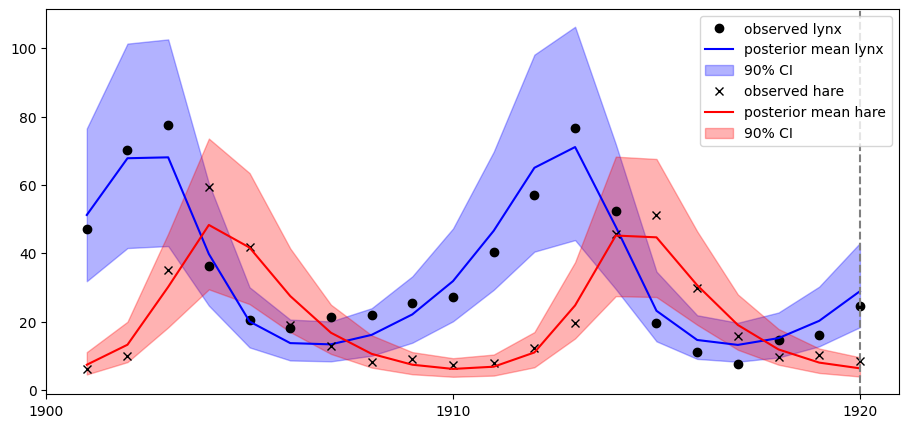

In [21]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(ts + 1900, y[:, 0], "ko", label="observed lynx")
ax.plot(ts + 1900, y_rep_mean[:, 0], color="blue", label="posterior mean lynx")
ax.fill_between(
    ts + 1900,
    y_rep_lower[:, 0],
    y_rep_upper[:, 0],
    color="blue",
    alpha=0.3,
    label="90% CI"
)

ax.plot(ts + 1900, y[:, 1], "kx", label="observed hare")
ax.plot(ts + 1900, y_rep_mean[:, 1], color="red", label="posterior mean hare")
ax.fill_between(
    ts + 1900,
    y_rep_lower[:, 1],
    y_rep_upper[:, 1],
    color="red",
    alpha=0.3,
    label="90% CI"
)

ax.axvline(x=1920, color="gray", linestyle="--")
plt.xticks(np.arange(1900, 1930, 10))

plt.legend()
plt.show()

Now, let's extend the predictions for the future.

In [22]:
lynx_hare_data["ts_future"] = list(range(max(ts) + 1, max(ts) + 100))
lynx_hare_data["N_future"] = 99

idata_v2 = bayesian.fit(lynx_hare_data, "lotka_volterra_model_v2.stan")

13:01:30 - cmdstanpy - INFO - CmdStan start processing
13:01:30 - cmdstanpy - INFO - Chain [1] start processing
13:01:30 - cmdstanpy - INFO - Chain [2] start processing
13:01:30 - cmdstanpy - INFO - Chain [3] start processing
13:01:30 - cmdstanpy - INFO - Chain [4] start processing
13:01:42 - cmdstanpy - INFO - Chain [4] done processing
13:01:43 - cmdstanpy - INFO - Chain [1] done processing
13:01:45 - cmdstanpy - INFO - Chain [3] done processing
13:01:51 - cmdstanpy - INFO - Chain [2] done processing
13:01:51 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: lognormal_lpdf: Location parameter[1] is -nan, but must be finite! (in 'lotka_volterra_model_v2.stan', line 47, column 17 to column 52)
	Exception: lognormal_lpdf: Location parameter[1] is -nan, but must be finite! (in 'lotka_volterra_model_v2.stan', line 47, column 17 to column 52)
	Exception: lognormal_lpdf: Location parameter[1] is -nan, but must be finite! (in 'lotka_volterra_model_v2.stan', line 47, column 1

                   Mean      MCSE    StdDev       MAD          5%         50%  \
lp__         -14.000800  0.056390  2.184210  2.069380  -17.917800  -13.587500   
theta[1]       0.552912  0.002016  0.064402  0.061859    0.450276    0.550284   
theta[2]       0.028081  0.000126  0.004224  0.004113    0.021661    0.027802   
theta[3]       0.791864  0.002814  0.090387  0.085519    0.656163    0.785227   
theta[4]       0.023784  0.000105  0.003534  0.003324    0.018497    0.023506   
...                 ...       ...       ...       ...         ...         ...   
ts_all[115]  115.000000       NaN  0.000000  0.000000  115.000000  115.000000   
ts_all[116]  116.000000       NaN  0.000000  0.000000  116.000000  116.000000   
ts_all[117]  117.000000       NaN  0.000000  0.000000  117.000000  117.000000   
ts_all[118]  118.000000       NaN  0.000000  0.000000  118.000000  118.000000   
ts_all[119]  119.000000       NaN  0.000000  0.000000  119.000000  119.000000   

                    95%  ES

In [23]:
t = np.concat([lynx_hare_data["ts"], lynx_hare_data["ts_future"]]) + 1900
ts = lynx_hare_data["ts"] + 1900

Unsurprisingly, the Credible Intervals get wider and wider.

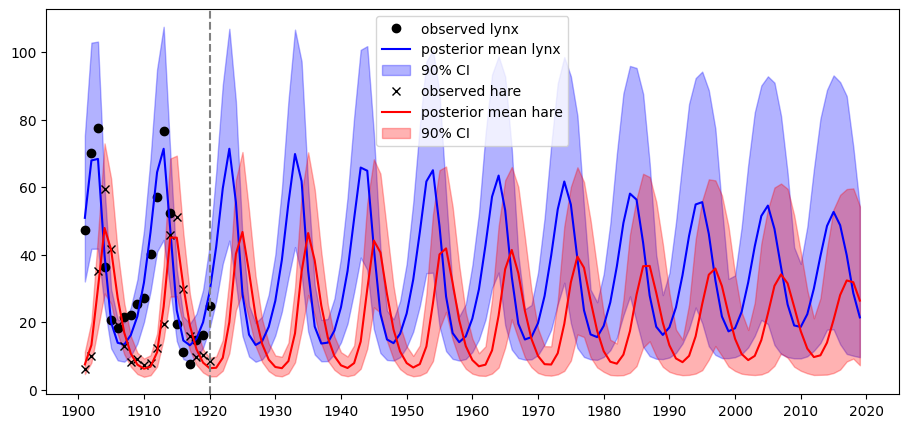

In [24]:
y_rep_mean = idata_v2["posterior_predictive"]["y_rep"].mean(dim=['chain', 'draw'])
y_rep_lower = idata_v2["posterior_predictive"]["y_rep"].quantile(0.05, dim=['chain', 'draw'])
y_rep_upper = idata_v2["posterior_predictive"]["y_rep"].quantile(0.95, dim=['chain', 'draw'])

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(ts, y[:, 0], "ko", label="observed lynx")
ax.plot(t, y_rep_mean[:, 0], color="blue", label="posterior mean lynx")
ax.fill_between(
    t,
    y_rep_lower[:, 0],
    y_rep_upper[:, 0],
    color="blue",
    alpha=0.3,
    label="90% CI"
)

ax.plot(ts, y[:, 1], "kx", label="observed hare")
ax.plot(t, y_rep_mean[:, 1], color="red", label="posterior mean hare")
ax.fill_between(
    t,
    y_rep_lower[:, 1],
    y_rep_upper[:, 1],
    color="red",
    alpha=0.3,
    label="90% CI"
)

ax.axvline(x=1920, color="gray", linestyle="--")
plt.xticks(np.arange(1900, 2030, 10))
plt.legend()

plt.savefig("img/03_continuos_system_predictions_bayesian.jpg")
plt.show()

## Agent-Based Modelling

The ABM's model is very similar to the Wolf-Sheep model example found in Mesa's docs, minus the Von-Neumann grid, which I changed since it was causing some weird spatial patterns. In this way, the model is not complicated. Hares eat preferably at their current location. If there is no food, they walk around. Preferably to cells where there is food and no lynxes. Lynxes eat at their current location, if there's no food they move to a neighbooring cell, preferably with hares. The final type of agent is the grass patch which grows at a fixed rate, can be eaten by hare and needs a time to regrow after being eaten. Both hares and lynxes have a probability to reproduce (asexually), a certain amount of energy that they spend and gain by walking and reproducing and by eating respectively. Agents are uniformly distributed in a 25 by 25 grid cell during their creation. We will be simulating 20 years worth of data.

In his book, Manzo puts forward the idea that if ABM modelers want to move past what he calls "toy models," they need to make sure their models are realistic. He specifically mentions three scales of Realism:

1. Theoretical Realism: use of well-established economic, psychological, or, in this case, ecological theory to specify how agents interact.
2. Input Realism: use of empirical data to initialize model parameters.
3. Output Realism: use of empirical data to calibrate model outputs.

Ideally, we would like our model to score high on each scale, but as I've mentioned before, I am not an ecologist. Even though I have some intuition about ways the model could be made more realistic, e.g., by making agents reproduce sexually or setting a maximum lifespan for each agent, I think the most fruitful way for me to move forward now is to look for Output Realism. Therefore, I have used black-box Bayesian Optimization to choose the simulation parameters in a way that most resembles the input data.

What do we know about the outcomes? Well, we know that both species haven't gone extinct so far and that there is a cyclic pattern in both populations' dynamics. Therefore, there are two objectives we want to optimize: the survival of both species at the end of each round of simulations and the presence of cycles in populations across time. I have used 10 simulations by trial and averaged the results in order to feed them to Bayesian Optimization.

Survival is rather easy to calculate; the less trivial thing is how to measure the cycles. For this, I calculate the average Dynamic Time Warping (DTW) distance between simulation and real data. The reason to use DTW is that it works better than Euclidean Distance to capture the shape of the signal, and not only its magnitude.

However, it is not so easy. Here, we face the challenge of equifinality, i.e., mutually exclusive parameter configurations can give rise to very similar simulated behavior. My approach is to filter the Pareto Frontier using some prior intuition, namely, hares reproduce faster than lynxes and lynxes' meals are much more nutritious than hares'.

Now, let me point out ways simulation helped me uncover patterns and raise hypotheses in a way the Bayesian Model couldn't, even if the simulated data is not a perfect match, e.g, no ten-year cycle.

1. Hare population dynamics seem to be dictated a lot more by their capacity to deplete their environment resources than by the lynx's dynamics. See the picture below. At the same time, the Lotka-Volterra equations provide no notion of a maximum population that the ecosystem is capable of supporting.

2. If we assume the first hypothesis is true, and the cycles on the hare dynamics are not caused solely by the lynx. It means that the clean cycles we see on lynx should be caused by confouding factors at least partially, like the presence of other species.

3. Equilibrium seems to be a lot more fragile than the beautiful ellipses seem to suggest, especially when simulated populations are small. I also don't have a way to make this statement precise, but it seems a lot easier to pick parameters that lead to extinction or erratic behavior than parameters that lead to perfect cycles.

4. Even though the Bayesian Credible Intervals get wider as our predictions get further into the future, it still feels like a self-fulfilling prophecy. Remember that I told you that the origin is a saddle point? This means that no matter how small the populations get, solutions will always form an ellipse around the equilibrium point.

Given what we have discussed, the Bayesian Model strikes me as a kind of Geocentric Model, i.e, a model capable of making accurate predictions, while being mechanistically wrong. That being said, the ABM is also far from perfect. We are making the coarse approximation of using one agent to represent a thousand individuals, while also ignoring the population's density. Each tick of the clock corresponds to one week, and I imagine these animals move a lot more in nature, but unfortunately, Mesa parallelism didn't play nicely with the Bayesian Optimization framework, and I had to make these simplifications so simulations didn't take too long.

Hopefully, I provided you with enough data, information, and suggestions on how to expand and improve these analyses. If you're still reading up until this point, I would love for you to, e.g., submit a PR for any of them. Or maybe you want to try new equations as shown below. First, try to think about which assumptions are encoded in them. How do they solve some of the issues mentioned before?

\begin{align*}
\frac{dx}{dt} & = r x \left(1-\frac{x}{k}\right) - \frac{\alpha x y}{\gamma + x} \\
\frac{dy}{dt} & = \beta \frac{\alpha x y}{\gamma + x} - \delta y
\end{align*}

Before we end, let me justify the title of the post. Do you know what also sounds unreasonable? The fact that I was able to intuit some of the hypotheses mentioned previously, knowing almost anything about Biology, only by playing with random numbers on a computer. Surprisingly, it appears that there's some evidence for some of them. Well, according to this article at least. I haven't researched extensively, but I would love to connect with someone who did.

## Closing thoughts

ABM, Bayesian Optimization, Dynamic Time Warping, Differential Equations... we've really thrown the kitchen sink at this problem, huh? So, in the end, what's the conclusion? What is going to happen to hares and lynxes in the future? It might seem a little anticlimactic, but the truth is that I don't know. One might say I Aint So Sure™. Besides pointing out the roles simulation might play and defending a plurality of methodological views, I think the big takeaway from this post is that we should expand and protect nature reserves if we care about protecting this ecosystem, since the hare-lynx population dynamics may not be the perfect prey-predator example, while also not being so well-understood as historically thought. 

## References

1. L2C https://l2c.dev.br/lp/
2. Lotka–Volterra equations: https://en.wikipedia.org/wiki/Lotka%E2%80%93Volterra_equations
3. Predator-Prey Population Dynamics: the Lotka-Volterra model in Stan: https://mc-stan.org/learn-stan/case-studies/lotka-volterra-predator-prey.html
4. Revisiting the Hare vs Lynx Cycle: https://www.ealt.ca/blog/hare-vs-lynx-cycle
5. Wolf-Sheep Predation Model: https://mesa.readthedocs.io/stable/examples/advanced/wolf_sheep.html
6. Mastering Linear Algebra: An Introduction with Applications https://www.amazon.com/Mastering-Linear-Algebra-Introduction-Applications/dp/1629977039
7. Elementary Differential Equations and Boundary Value Problems https://www.amazon.com/Elementary-Differential-Equations-Boundary-Problems-ebook/dp/B073WNJ13R?_encoding=UTF8&pd_rd_w=yte4B&content-id=amzn1.sym.9c9a049f-252a-49d9-a8c2-e300a1663200&pf_rd_p=9c9a049f-252a-49d9-a8c2-e300a1663200&pf_rd_r=145-6195030-5521945&pd_rd_wg=t9HUE&pd_rd_r=163a352e-1357-4138-b4d3-0a520f48c94f